<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        t-SNE: Vecindades Locales en Dos Dimensiones 🗺️
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Machine Learning
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 05
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Machine%20Learning/05%20-%20Reduccion%20de%20Dimensionalidad/01_tSNE.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## Objetivos de Aprendizaje 🔎

Este cuaderno desarrolla la segunda técnica de la **Sección 2.6 (*Dimensionality reduction*)**: **t-SNE** (*t-distributed Stochastic Neighbor Embedding*; van der Maaten & Hinton, 2008). Es la técnica no lineal más usada para **visualizar** datos de alta dimensión, y también la más **malinterpretada**: sus mapas son tan convincentes que se les atribuye un significado (tamaños de grupo, distancias entre grupos) que el algoritmo **no garantiza**. Aquí **lo derivamos, lo programamos desde cero (versión exacta $O(n^2)$) y lo contrastamos con `scikit-learn`**, verificando con `assert` todo lo que **sí** es exacto.

Al terminar podrás:

1. **Explicar** la idea de t-SNE: convertir distancias en **probabilidades de vecindad** y buscar un mapa 2D cuyas vecindades se parezcan a las originales.
2. **Calcular desde cero** las afinidades gaussianas $p_{j\mid i}$ con la **búsqueda binaria de $\sigma_i$** que fija la **perplejidad**, simetrizarlas y **verificar** que cada fila alcanza la perplejidad objetivo.
3. **Justificar** el uso de la **distribución $t$ de Student** (cola pesada) en baja dimensión como solución al **problema de aglomeración** (*crowding problem*).
4. **Derivar** la función de costo $\mathrm{KL}(P\Vert Q)$ y su **gradiente**, y **verificarlo** contra diferencias finitas.
5. **Implementar** t-SNE exacto desde cero (**exageración temprana**, *momentum* y ganancias adaptativas) y **compararlo** con `sklearn.manifold.TSNE` mediante la **KL final** y la ***trustworthiness***, entendiendo **por qué no se puede exigir igualdad exacta**.
6. **Medir** el efecto de la **perplejidad**, de las **iteraciones** y de la **inicialización**.
7. **Evitar las trampas de interpretación**: tamaños y distancias entre grupos no significan nada, estructura falsa en ruido, resultados distintos por semilla y **ausencia de transformación** para datos nuevos; conocer el costo, **Barnes–Hut** y **UMAP**.

> 📍 **Dónde estamos:** Módulo 05, cuaderno 2 de 3. Venimos de [PCA](00_PCA.ipynb) (la técnica lineal y global). Sigue [Isomap y variedades](02_Isomap_y_Variedades.ipynb). La maldición de la dimensionalidad que motiva todo el módulo se desarrolló en la [Introducción al Capítulo 2](../04%20-%20Clustering%20No%20Supervisado/00_Introduccion_Cap2_y_No_Supervisado.ipynb) y **no se repite**; la silueta y otras métricas para evaluar agrupamientos, en el [cuaderno 04 del Módulo 04](../04%20-%20Clustering%20No%20Supervisado/04_Metricas_de_Clustering.ipynb).

> 🔗 **Para no repetir:** t-SNE aparece solo como herramienta de visualización en otros cursos; aquí nos centramos en **qué optimiza, cómo se implementa y cómo se lee un mapa**.

---
## Recursos Recomendados 📚

### 📖 Libros de Referencia:
- *Hands-On Machine Learning with Scikit-Learn and PyTorch* — **Aurélien Géron** (O'Reilly, 2025). Cap. 7 (*Dimensionality Reduction*): *Other Dimensionality Reduction Techniques* (describe `TSNE`, `Isomap`, `MDS`, LDA y menciona UMAP; advierte que t-SNE se usa sobre todo para visualización, **no** como preprocesamiento de modelos) y *Manifold Learning* (disponible en `Machine Learning/Libros/`).
- *Machine Learning Theory and Applications* — **Xavier Vasques** (Wiley, 2024). Cap. 2, §2.5.1.5 (*The t-Distributed Stochastic Neighbor Embedding Technique*) y §2.5.1.6 (*More Manifold Learning Techniques*) (disponible en `Machine Learning/Libros/`).
- van der Maaten, L. & Hinton, G. (2008), *Visualizing data using t-SNE*, **Journal of Machine Learning Research** 9: 2579–2605 *(citado de memoria, verificar)*. Es el artículo original; se apoya en Hinton, G. & Roweis, S. (2002), *Stochastic neighbor embedding*, **NIPS 15** *(citado de memoria, verificar)*.
- van der Maaten, L. (2014), *Accelerating t-SNE using tree-based algorithms*, **JMLR** 15: 3221–3245 *(citado de memoria, verificar)*: la aproximación de **Barnes–Hut**.
- Wattenberg, M., Viégas, F. & Johnson, I. (2016), *How to use t-SNE effectively*, **Distill** *(citado de memoria, verificar)*: guía interactiva de trampas de interpretación.
- Kobak, D. & Berens, P. (2019), *The art of using t-SNE for single-cell transcriptomics*, **Nature Communications** 10: 5416 *(citado de memoria, verificar)*; Kobak, D. & Linderman, G. C. (2021), *Initialization is critical for preserving global data structure in both t-SNE and UMAP*, **Nature Biotechnology** 39: 156–157 *(citado de memoria, verificar)*.
- McInnes, L., Healy, J. & Melville, J. (2018), *UMAP: Uniform Manifold Approximation and Projection for dimension reduction*, **arXiv:1802.03426** *(citado de memoria, verificar)*.
- Venna, J. & Kaski, S. (2006), *Local multidimensional scaling*, **Neural Networks** 19(6–7): 889–899 *(citado de memoria, verificar)*: origen de las medidas de *trustworthiness* y *continuity*.

### 🌐 Documentación y Recursos Online:
- [scikit-learn: Manifold learning — t-SNE](https://scikit-learn.org/stable/modules/manifold.html#t-sne) · [`TSNE`](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) · [`trustworthiness`](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.trustworthiness.html)
- [Distill: *How to Use t-SNE Effectively*](https://distill.pub/2016/misread-tsne/)

---
## 1. La Idea: Conservar las Vecindades 🏘️

PCA (cuaderno anterior) busca una **proyección lineal** que preserve la **varianza global**. Eso funciona si los grupos se separan en direcciones de gran varianza, pero **no** si la estructura es curva o si los grupos solo se distinguen por **quiénes son vecinos de quiénes**. t-SNE cambia el objetivo:

> **Construir un mapa de baja dimensión (casi siempre 2D) en el que los puntos que eran vecinos en el espacio original sigan siendo vecinos.**

Para lograrlo traduce las distancias a **probabilidades**:

1. En **alta dimensión**, la probabilidad de que $\mathbf x_i$ «elija» a $\mathbf x_j$ como vecino es una **gaussiana** centrada en $\mathbf x_i$ cuyo ancho $\sigma_i$ se ajusta **a la densidad local** (§2).
2. En **baja dimensión**, la misma idea con una **$t$ de Student de cola pesada** (§3).
3. Se mueven los puntos $\mathbf y_i$ del mapa para que ambas distribuciones se parezcan, minimizando la **divergencia de Kullback–Leibler** (§3–§4).

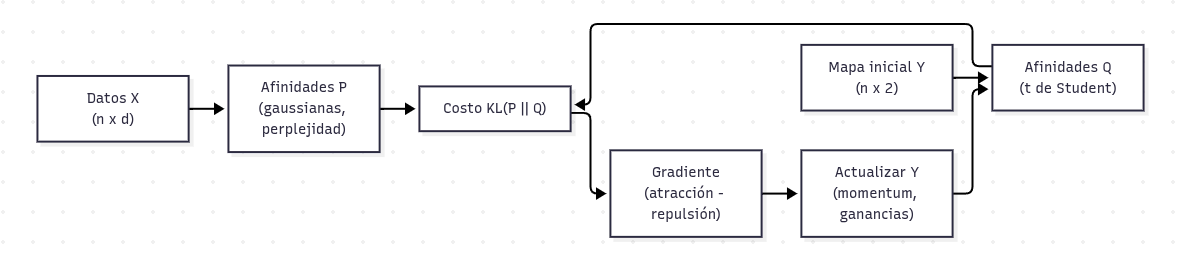

**Datos de trabajo.** Usamos un subconjunto **equilibrado de 500 dígitos** (50 por clase) de `load_digits` (64 píxeles escalados a $[0,1]$): es suficientemente grande para ver estructura y suficientemente pequeño para que el t-SNE exacto $O(n^2)$ escrito desde cero corra en segundos.

In [ ]:
# ============================================================
# Configuracion inicial y datos: 500 digitos (50 por clase)
# ============================================================
# !pip install -q numpy pandas matplotlib seaborn scikit-learn scipy

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import squareform
from sklearn.datasets import load_digits, make_blobs
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
PALETA = ["#2563eb", "#dc2626", "#16a34a", "#f59e0b", "#7c3aed", "#0891b2", "#db2777", "#65a30d", "#78350f", "#475569"]

Xd, yd = load_digits(return_X_y=True)
r = np.random.RandomState(SEED)
idx = np.concatenate([r.choice(np.where(yd == c)[0], 50, replace=False) for c in range(10)])
X, y = Xd[idx] / 16.0, yd[idx]                                   # 500 digitos, pixeles en [0, 1]
n = len(X)

def dist2(A):
    """Matriz de distancias euclidianas AL CUADRADO entre todas las filas de A."""
    s = (A ** 2).sum(axis=1)
    D = s[:, None] + s[None, :] - 2 * A @ A.T
    np.fill_diagonal(D, 0.0)
    return np.maximum(D, 0.0)

def tsne_sklearn(iteraciones=1000, **kw):
    """TSNE de sklearn compatible entre versiones: 'max_iter' (>= 1.5) o 'n_iter' (versiones anteriores)."""
    try:
        return TSNE(max_iter=iteraciones, **kw)
    except TypeError:
        return TSNE(n_iter=iteraciones, **kw)

def pintar(ax, Y, titulo, y=y):
    for c in range(10):
        ax.scatter(Y[y == c, 0], Y[y == c, 1], s=14, color=PALETA[c], label=str(c), alpha=0.85)
    ax.set_title(titulo, fontweight="bold", fontsize=10); ax.set_xticks([]); ax.set_yticks([])

print(f"{n} dígitos, {X.shape[1]} píxeles, {len(np.unique(y))} clases. Versiones: ver cabecera del cuaderno.")

---
## 2. Afinidades en Alta Dimensión: Perplejidad y Búsqueda Binaria de $\sigma_i$ 🎛️

### 2.1 Probabilidades condicionales

Para cada punto $\mathbf x_i$ definimos la probabilidad de que elija a $\mathbf x_j$ como vecino:

$$p_{j\mid i}=\frac{\exp\!\big(-\|\mathbf x_i-\mathbf x_j\|^2/2\sigma_i^2\big)}{\sum_{k\ne i}\exp\!\big(-\|\mathbf x_i-\mathbf x_k\|^2/2\sigma_i^2\big)},\qquad p_{i\mid i}=0 .$$

Cada fila $P_i=(p_{j\mid i})_j$ es una distribución de probabilidad. El ancho $\sigma_i$ es **propio de cada punto**: en regiones densas hace falta un $\sigma_i$ pequeño y en regiones dispersas uno grande, para que **todos tengan «aproximadamente los mismos vecinos efectivos»**.

### 2.2 Perplejidad

Se mide ese número de vecinos efectivos con la **perplejidad** de la fila,

$$\operatorname{Perp}(P_i)=2^{H(P_i)}\qquad\text{con}\qquad H(P_i)=-\sum_j p_{j\mid i}\log_2 p_{j\mid i}$$

(si $H$ se mide en nats, $\operatorname{Perp}=e^{H}$; el valor es el mismo). Es el parámetro más importante de t-SNE: una distribución uniforme sobre $k$ vecinos tiene perplejidad exactamente $k$, de modo que **perplejidad $\approx$ número de vecinos que cada punto «tiene en cuenta»** (valores típicos: 5–50). La entropía $H(P_i)$ es **estrictamente creciente** en $\sigma_i$ (de $0$ cuando $\sigma_i\to0$, un único vecino, a $\log_2(n-1)$ cuando $\sigma_i\to\infty$, distribución uniforme), así que para cada punto existe **un único $\sigma_i$** con la perplejidad deseada y se encuentra por **búsqueda binaria** (bisección) sobre $\beta_i=1/(2\sigma_i^2)$.

### 2.3 Simetrización

Como $\sigma_i$ difiere entre puntos, $p_{j\mid i}\neq p_{i\mid j}$. t-SNE usa la versión simétrica

$$p_{ij}=\frac{p_{j\mid i}+p_{i\mid j}}{2n},\qquad \sum_{i\ne j}p_{ij}=1,\quad p_{ij}=p_{ji}.$$

Además de simplificar el gradiente, garantiza $\sum_j p_{ij}>\frac1{2n}$: un *outlier* (cuyos $p_{j\mid i}$ son diminutos) sigue aportando al costo y no queda «suelto» en el mapa.

> 🔧 **Detalles de implementación** (como en `scikit-learn`): se usan las distancias **al cuadrado**, la bisección se hace sobre $\beta_i$ con tolerancia $10^{-5}$ en la entropía, y se resta la distancia mínima antes de exponenciar para evitar *underflow*. En `method="barnes_hut"` solo se usan los $3\cdot\text{perplejidad}$ vecinos más cercanos (matriz dispersa); en `method="exact"` se usa la matriz completa, que es lo que programamos.

In [ ]:
# ============================================================
# 2. Afinidades P DESDE CERO: busqueda binaria de sigma_i para una perplejidad objetivo
# ============================================================
def probabilidades_condicionales(D2, perplejidad, tol=1e-5, max_iter=100):
    """Matriz P_cond (n, n) con p_{j|i} y vector beta_i = 1 / (2 sigma_i^2), por biseccion sobre beta (D2: distancias al cuadrado)."""
    n = len(D2)
    P, betas = np.zeros((n, n)), np.zeros(n)
    objetivo = np.log(perplejidad)                                   # H objetivo en nats: log(Perp)
    for i in range(n):
        d = np.delete(D2[i], i) - np.delete(D2[i], i).min()          # sin el propio punto; se resta el minimo (estabilidad numerica)
        lo, hi, beta = 0.0, np.inf, 1.0
        for _ in range(max_iter):
            e = np.exp(-d * beta); s = e.sum(); p = e / s
            H = np.log(s) + beta * (d * p).sum()                     # entropia (nats) de la fila: H = log s + beta * E[d]
            if abs(H - objetivo) < tol:
                break
            if H > objetivo:                                         # distribucion demasiado ancha -> subir beta (bajar sigma)
                lo = beta; beta = beta * 2 if np.isinf(hi) else (beta + hi) / 2
            else:                                                    # demasiado concentrada -> bajar beta
                hi = beta; beta = (beta + lo) / 2
        P[i, np.arange(n) != i] = p
        betas[i] = beta
    return P, betas

def perplejidad_filas(P):
    """Perplejidad 2^H de cada fila de una matriz de probabilidades condicionales."""
    H = -(P * np.log2(np.where(P > 0, P, 1.0))).sum(axis=1)
    return 2 ** H

def afinidades_simetricas(D2, perplejidad):
    Pc, betas = probabilidades_condicionales(D2, perplejidad)
    P = (Pc + Pc.T) / (2 * len(D2))                                  # simetrizar: p_ij = (p_j|i + p_i|j) / 2n
    return P, Pc, betas

PERPLEJIDAD = 30.0
t0 = time.time()
D2x = dist2(X)
P, Pcond, betas = afinidades_simetricas(D2x, PERPLEJIDAD)
print(f"Afinidades P calculadas en {time.time() - t0:.2f} s")

# --- Verificaciones EXACTAS ---
perp = perplejidad_filas(Pcond)
assert np.abs(perp - PERPLEJIDAD).max() < 1e-2                       # cada fila alcanza la perplejidad objetivo
assert np.allclose(Pcond.sum(axis=1), 1.0)                           # cada fila es una distribucion de probabilidad
assert np.allclose(P, P.T) and np.isclose(P.sum(), 1.0) and np.all(np.diag(P) == 0)    # P simetrica, suma 1, diagonal nula
assert np.all(P.sum(axis=1) > 1 / (2 * n))                           # ningun punto queda "suelto"
print(f"Perplejidad de las 500 filas: mín = {perp.min():.4f}, máx = {perp.max():.4f} (objetivo {PERPLEJIDAD}); P simétrica con suma 1.")

# --- Comparacion con la P interna de sklearn (funcion PRIVADA: se intenta y, si no existe, se avisa) ---
try:
    from sklearn.manifold._t_sne import _joint_probabilities
    P_sk = squareform(_joint_probabilities(D2x.astype(np.float32), PERPLEJIDAD, 0))   # sklearn trabaja en float32
    dif = np.abs(P - P_sk).max()
    assert dif < 1e-8, dif                                           # P ~ 1e-4..1e-3: diferencia de redondeo float32
    print(f"P propia == P interna de sklearn (max |diferencia| = {dif:.1e}; los valores de P llegan a {P.max():.1e}).")
except Exception as e:
    print("(Comparación con la función privada de sklearn omitida en esta versión:", type(e).__name__, ")")

# --- Visualizacion: sigma_i adaptativo y perplejidad como funcion de sigma ---
sigma = np.sqrt(1 / (2 * betas))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].hist(sigma, bins=30, color=PALETA[0], alpha=0.85)
axes[0].set_xlabel(r"$\sigma_i$ (ancho gaussiano de cada punto)"); axes[0].set_ylabel("Número de puntos")
axes[0].set_title(r"Cada punto tiene su propio $\sigma_i$: se adapta a la densidad local", fontweight="bold", fontsize=10)
i0 = 0
d_i = np.delete(D2x[i0], i0)
sigmas = np.logspace(-1.5, 1.0, 60)
perps = [perplejidad_filas((lambda e: (e / e.sum())[None, :])(np.exp(-(d_i - d_i.min()) / (2 * s ** 2))))[0] for s in sigmas]
assert np.all(np.diff(perps) > 0)                                    # la perplejidad crece estrictamente con sigma -> la solucion es unica
axes[1].semilogx(sigmas, perps, color=PALETA[1], lw=2.5)
axes[1].axhline(PERPLEJIDAD, color="black", ls=":", label=f"objetivo = {PERPLEJIDAD:.0f}")
axes[1].axvline(sigma[i0], color=PALETA[2], ls="--", label=rf"$\sigma_0$ hallado = {sigma[i0]:.3f}")
axes[1].set_xlabel(r"$\sigma$"); axes[1].set_ylabel("Perplejidad de la fila del punto 0")
axes[1].set_title("La perplejidad crece de forma monótona con $\\sigma$: la bisección converge", fontweight="bold", fontsize=10); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

---
##### 🛠️ Práctica 1: Menos vecinos efectivos: perplejidad 10 en lugar de 30

En la Sección 2 fijamos `PERPLEJIDAD = 30` y la bisección halló un $\sigma_i$ por punto. Repite el cálculo con una perplejidad **más pequeña** (cada punto tendrá en cuenta menos vecinos) usando `D2x`, `probabilidades_condicionales`, `perplejidad_filas`, `betas` y `PERPLEJIDAD`:

1. Calcula `Pc_10, betas_10 = probabilidades_condicionales(D2x, 10.0)`.
2. Verifica con `assert` que **cada** una de las 500 filas de `Pc_10` alcanza perplejidad $10$ (tolerancia $10^{-2}$, como en el cuaderno).
3. Recuerda que $\beta_i=1/(2\sigma_i^2)$: obtén `sigma_10` y `sigma_30` (este último a partir de `betas`) y guarda sus promedios en `media_sigma_10` y `media_sigma_30`.
4. Verifica con `assert` que `media_sigma_10 < media_sigma_30` e imprime ambos. Comenta: ¿por qué una perplejidad menor exige gaussianas más estrechas?

In [ ]:
# Escribe tu código aquí

# Pc_10, betas_10 = probabilidades_condicionales(...)
# perp_10 = perplejidad_filas(...)
# assert ...
# sigma_10 = np.sqrt(1 / (2 * betas_10))
# sigma_30 = ...
# media_sigma_10, media_sigma_30 = ...
# assert ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) Mismas distancias, perplejidad objetivo 10
Pc_10, betas_10 = probabilidades_condicionales(D2x, 10.0)

# 2) Cada fila debe alcanzar la perplejidad pedida
perp_10 = perplejidad_filas(Pc_10)
assert np.abs(perp_10 - 10.0).max() < 1e-2

# 3) beta = 1 / (2 sigma^2)  ->  sigma = sqrt(1 / (2 beta))
sigma_10 = np.sqrt(1 / (2 * betas_10))
sigma_30 = np.sqrt(1 / (2 * betas))                   # 'betas' viene de PERPLEJIDAD = 30
media_sigma_10, media_sigma_30 = sigma_10.mean(), sigma_30.mean()

# 4) Menos vecinos efectivos -> gaussianas mas estrechas
assert media_sigma_10 < media_sigma_30
print(f"sigma medio con perplejidad 10: {media_sigma_10:.3f} | con perplejidad {PERPLEJIDAD:.0f}: {media_sigma_30:.3f}")
print("Para que 'cuente' solo ~10 vecinos, la gaussiana debe ser mas estrecha (sigma menor): la perplejidad crece de forma monotona con sigma.")
```
</details>

---


---
## 3. Baja Dimensión: la $t$ de Student, el Costo KL y su Gradiente 📉

### 3.1 Afinidades en el mapa y el problema de aglomeración

En el mapa $\mathbf y_1,\dots,\mathbf y_n\in\mathbb{R}^2$ se define

$$q_{ij}=\frac{\big(1+\|\mathbf y_i-\mathbf y_j\|^2\big)^{-1}}{\sum_{k\ne l}\big(1+\|\mathbf y_k-\mathbf y_l\|^2\big)^{-1}},\qquad q_{ii}=0,$$

que es una **distribución $t$ de Student con 1 grado de libertad** (la de Cauchy). ¿Por qué no otra gaussiana? Por el ***crowding problem***: en $d$ dimensiones un punto puede tener muchos vecinos a distancia moderada, pero en 2D **no hay «espacio»** para colocarlos todos igual de lejos. Con una gaussiana en el mapa, para reproducir una afinidad moderada hay que colocar los puntos muy cerca, y la suma de muchas fuerzas atractivas suaves **aplasta todo hacia el centro**, sin huecos entre grupos. La cola pesada de la $t$ resuelve esto: una afinidad pequeña se alcanza a una distancia **mucho mayor**, de modo que los puntos «moderadamente lejanos» pueden **separarse** y los grupos se despegan. Además, $(1+d^2)^{-1}$ decae como una ley de potencias ($\sim d^{-2}$), es casi invariante de escala para $d$ grande y **no requiere calcular exponenciales**.

### 3.2 Función de costo

Se minimiza la divergencia de Kullback–Leibler entre las dos distribuciones conjuntas:

$$C=\mathrm{KL}(P\Vert Q)=\sum_{i\ne j}p_{ij}\log\frac{p_{ij}}{q_{ij}} .$$

Es **asimétrica**, y eso define el carácter de t-SNE: si dos puntos son vecinos ($p_{ij}$ grande) pero quedan lejos ($q_{ij}$ pequeño) el término es **muy grande**; si dos puntos **no** son vecinos ($p_{ij}\approx0$) pero se colocan cerca, el costo es **casi nulo**. Resultado: t-SNE **preserva vecindades locales** y es **permisivo con la estructura global**.

### 3.3 Gradiente

Sea $w_{ij}=(1+\|\mathbf y_i-\mathbf y_j\|^2)^{-1}$ y $Z=\sum_{k\ne l}w_{kl}$, de modo que $q_{ij}=w_{ij}/Z$. Como $\sum p_{ij}=1$, $C=\sum p_{ij}\log p_{ij}-\sum p_{ij}\log w_{ij}+\log Z$. Derivando respecto de $\mathbf y_i$ (cada par aparece dos veces, como $(i,j)$ y $(j,i)$) y usando $\partial w_{ij}/\partial\mathbf y_i=-2\,w_{ij}^2(\mathbf y_i-\mathbf y_j)$:

$$\frac{\partial}{\partial \mathbf y_i}\Big(-\sum p_{kl}\log w_{kl}\Big)=4\sum_j p_{ij}\,w_{ij}(\mathbf y_i-\mathbf y_j),\qquad \frac{\partial \log Z}{\partial\mathbf y_i}=-4\sum_j q_{ij}\,w_{ij}(\mathbf y_i-\mathbf y_j),$$

y, sumando,

$$\boxed{\frac{\partial C}{\partial\mathbf y_i}=4\sum_{j\ne i}\big(p_{ij}-q_{ij}\big)\,\big(\mathbf y_i-\mathbf y_j\big)\big(1+\|\mathbf y_i-\mathbf y_j\|^2\big)^{-1}}$$

**Interpretación física:** cada par $(i,j)$ ejerce un **resorte** sobre $\mathbf y_i$: **atrae** si $p_{ij}>q_{ij}$ (eran más vecinos de lo que el mapa dice) y **repele** si $p_{ij}<q_{ij}$. El mapa converge cuando las fuerzas se equilibran.

Verificamos dos cosas: (i) cuánto más lejos puede colocar el mapa a un par con la misma afinidad en la $t$ que en la gaussiana, y (ii) **que el gradiente analítico coincide con diferencias finitas** (esto **sí** es exacto, a diferencia de la comparación con `sklearn`).

In [ ]:
# ============================================================
# 3. Costo KL y gradiente analitico; verificacion con diferencias finitas; cola pesada vs gaussiana
# ============================================================
def kl_y_gradiente(Y, P, P_kl=None, calcular_kl=True):
    """Gradiente de KL(P||Q) respecto de Y (n, 2) y, opcionalmente, el valor de KL(P_kl||Q) (por defecto P_kl = P)."""
    W = 1.0 / (1.0 + dist2(Y)); np.fill_diagonal(W, 0.0)             # w_ij = (1 + ||yi - yj||^2)^-1
    Q = W / W.sum()                                                  # q_ij = w_ij / Z
    PQ = (P - Q) * W
    grad = 4.0 * (PQ.sum(axis=1)[:, None] * Y - PQ @ Y)              # 4 * sum_j (p_ij - q_ij) w_ij (y_i - y_j)
    kl = None
    if calcular_kl:
        Pk = P if P_kl is None else P_kl
        m = Pk > 0
        kl = float((Pk[m] * np.log(Pk[m] / np.maximum(Q[m], 1e-12))).sum())
    return kl, grad

# (i) Diferencias finitas centrales sobre un problema pequeno (25 puntos en 5 D)
r = np.random.RandomState(0)
Xp = r.randn(25, 5)
Pp, _, _ = afinidades_simetricas(dist2(Xp), 5.0)
Yp = r.randn(25, 2)
_, g_analitico = kl_y_gradiente(Yp, Pp)
g_numerico, h = np.zeros_like(Yp), 1e-6
for i in range(Yp.shape[0]):
    for k in range(2):
        Yp[i, k] += h; kl_mas, _ = kl_y_gradiente(Yp, Pp)
        Yp[i, k] -= 2 * h; kl_menos, _ = kl_y_gradiente(Yp, Pp)
        Yp[i, k] += h
        g_numerico[i, k] = (kl_mas - kl_menos) / (2 * h)
err_rel = np.abs(g_analitico - g_numerico).max() / np.abs(g_numerico).max()
assert err_rel < 1e-6, err_rel
print(f"Gradiente analítico vs diferencias finitas centrales: error relativo máximo = {err_rel:.1e}  → verificado.")

# (ii) Cola pesada: distancia en el mapa necesaria para una afinidad relativa s
s = np.array([0.5, 0.2, 0.1, 0.05, 0.01, 0.001])
d_gauss, d_t = np.sqrt(-2 * np.log(s)), np.sqrt(1 / s - 1)           # gaussiana (sigma = 1): exp(-d^2/2) = s ;  t de Student: 1/(1+d^2) = s
display(pd.DataFrame({"afinidad relativa s": s, "distancia (gaussiana, σ=1)": d_gauss, "distancia (t de Student)": d_t, "cociente t / gauss": d_t / d_gauss}).round(2))

dd = np.linspace(0, 8, 400)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(dd, np.exp(-dd ** 2 / 2), color=PALETA[0], lw=2.5, label=r"Gaussiana $e^{-d^2/2}$")
axes[0].plot(dd, 1 / (1 + dd ** 2), color=PALETA[1], lw=2.5, label=r"$t$ de Student $(1+d^2)^{-1}$")
axes[0].set_xlabel("Distancia $d$ en el mapa"); axes[0].set_ylabel("Afinidad (sin normalizar)"); axes[0].legend()
axes[0].set_title("Escala lineal: ambas núcleos parecen similares", fontweight="bold", fontsize=10)
axes[1].semilogy(dd, np.exp(-dd ** 2 / 2), color=PALETA[0], lw=2.5, label="Gaussiana")
axes[1].semilogy(dd, 1 / (1 + dd ** 2), color=PALETA[1], lw=2.5, label="$t$ de Student (cola pesada)")
axes[1].set_xlabel("Distancia $d$ en el mapa"); axes[1].set_ylabel("Afinidad (escala log)"); axes[1].set_ylim(1e-12, 2); axes[1].legend()
axes[1].set_title("Escala log: la cola pesada permite separar puntos 'moderadamente lejanos'", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

---
##### 🛠️ Práctica 2: Tu propio descenso de gradiente (sin momentum)

En la Sección 3 verificamos que `kl_y_gradiente(Y, P)` devuelve el costo $\mathrm{KL}(P\Vert Q)$ y su gradiente. Úsalo para escribir el optimizador **más simple posible** (descenso de gradiente puro, sin *momentum*, ganancias ni exageración temprana) con `X`, `n`, `P` y `trustworthiness`:

1. Crea `Y = np.random.RandomState(0).randn(n, 2) * 1e-2` y guarda una copia en `Y_ini`.
2. Repite 300 veces: calcula `kl, grad = kl_y_gradiente(Y, P)` y actualiza `Y = Y - tasa * grad` con `tasa = 100.0`. Guarda el costo inicial en `kl_ini` (el de la primera iteración) y el final en `kl_fin = kl_y_gradiente(Y, P)[0]`.
3. Calcula `trust_ini` y `trust_fin` con `trustworthiness(X, ..., n_neighbors=10)` para `Y_ini` y para `Y`.
4. Verifica con `assert` que la KL bajó y que la *trustworthiness* mejoró. Imprime los cuatro valores.

In [ ]:
# Escribe tu código aquí

# Y = np.random.RandomState(0).randn(n, 2) * 1e-2
# Y_ini = Y.copy()
# tasa = 100.0
# for it in range(300):
#     kl, grad = kl_y_gradiente(Y, P)
#     if it == 0: kl_ini = kl
#     Y = Y - ...
# kl_fin = kl_y_gradiente(Y, P)[0]
# trust_ini = trustworthiness(X, Y_ini, n_neighbors=10)
# trust_fin = ...
# assert ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) Mapa inicial diminuto y aleatorio
Y = np.random.RandomState(0).randn(n, 2) * 1e-2
Y_ini = Y.copy()

# 2) Descenso de gradiente puro: Y <- Y - tasa * gradiente
tasa = 100.0
for it in range(300):
    kl, grad = kl_y_gradiente(Y, P)
    if it == 0:
        kl_ini = kl                                   # costo del mapa inicial
    Y = Y - tasa * grad
kl_fin = kl_y_gradiente(Y, P)[0]

# 3) Calidad de las vecindades antes y despues
trust_ini = trustworthiness(X, Y_ini, n_neighbors=10)
trust_fin = trustworthiness(X, Y, n_neighbors=10)

# 4) El costo baja y los vecinos del mapa se parecen mas a los originales
assert kl_fin < kl_ini and trust_fin > trust_ini
print(f"KL: {kl_ini:.3f} -> {kl_fin:.3f} | trustworthiness: {trust_ini:.3f} -> {trust_fin:.3f}")
print("Incluso el descenso mas simple reduce la KL; el momentum, las ganancias y la exageracion temprana del cuaderno solo lo vuelven mas rapido y mas fiable.")
```
</details>

---


---
## 4. t-SNE Exacto Desde Cero y Comparación con `scikit-learn` ⚙️

### 4.1 El algoritmo de optimización

El costo no es convexo y se minimiza con **descenso de gradiente con *momentum*** (van der Maaten & Hinton, 2008):

$$\mathbf Y^{(t)}=\mathbf Y^{(t-1)}+\eta\,\mathbf g^{(t)}+\alpha(t)\big(\mathbf Y^{(t-1)}-\mathbf Y^{(t-2)}\big),$$

con tres ingredientes que **sí importan** en la práctica:

1. **Ganancias adaptativas** (Jacobs, 1988): cada coordenada tiene una ganancia que **sube** (+0.2) si el gradiente mantiene el sentido de la última actualización y **baja** (×0.8) si lo invierte, con mínimo 0.01.
2. ***Momentum* en dos fases:** $\alpha=0.5$ al inicio y $\alpha=0.8$ después de las primeras 250 iteraciones.
3. **Exageración temprana:** durante las primeras 250 iteraciones se multiplica $P$ por un factor (12 en `scikit-learn`). Con $p_{ij}$ mayores que cualquier $q_{ij}$ posible, los grupos se **contraen y se mueven libremente** unos respecto de otros (como bolas elásticas), lo que facilita encontrar una buena disposición global antes de refinar.

**Inicialización y tasa de aprendizaje.** `scikit-learn` (desde 1.2) usa por defecto `init="pca"` (los dos primeros componentes escalados a desviación estándar $10^{-4}$) y `learning_rate="auto"` $=\max(n/\text{exageración}/4,\ 50)$. Nosotros replicamos exactamente esas elecciones.

### 4.2 ¿Qué podemos exigir en la comparación con `scikit-learn`?

Hay cosas **exactas**: la matriz $P$ (verificada arriba) y el gradiente (verificado con diferencias finitas). Pero el **resultado final de la optimización no tiene por qué coincidir** punto a punto con el de otra implementación:

- el problema es **no convexo** y el mapa depende de la **inicialización y la semilla**;
- los errores de redondeo (`float32` en `scikit-learn`, `float64` aquí) se **amplifican** en cientos de iteraciones caóticas;
- el mapa solo está definido salvo **rotaciones, reflexiones y traslaciones** (el costo solo depende de distancias).

Por eso comparamos la **calidad**: el valor final de $\mathrm{KL}(P\Vert Q)$ (con la misma $P$) y la ***trustworthiness*** (Venna & Kaski, 2006), que mide qué fracción de los vecinos del mapa lo eran también en el espacio original (1 = perfecto), dentro de una **tolerancia** (5 % en la KL y 0.02 en la *trustworthiness*) que es del orden de la **variabilidad entre semillas** de la propia técnica (§5).

In [ ]:
# ============================================================
# 4. t-SNE exacto DESDE CERO (O(n^2)): exageracion temprana, momentum en dos fases y ganancias adaptativas
# ============================================================
def inicializacion_pca(X, escala=1e-4):
    """Dos primeros componentes principales, reescalados a desviacion estandar 1e-4 (la inicializacion 'pca' de sklearn)."""
    Xc = X - X.mean(axis=0)
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    Y0 = Xc @ Vt[:2].T
    return Y0 / np.std(Y0[:, 0]) * escala

def tsne_desde_cero(P, Y0, max_iter=1000, exageracion=12.0, iter_exageracion=250, tasa=None, guardar=()):
    """Descenso de gradiente con momentum (0.5 -> 0.8), ganancias adaptativas y exageracion temprana.
    Devuelve el mapa final, la historia [(iteracion, KL)] y capturas del mapa en las iteraciones de 'guardar'."""
    n = len(P)
    tasa = max(n / exageracion / 4.0, 50.0) if tasa is None else tasa           # learning_rate = "auto" de sklearn
    Y, actualizacion, ganancias = Y0.copy(), np.zeros_like(Y0), np.ones_like(Y0)
    P_exag = P * exageracion
    historia, capturas = [], {}
    for it in range(max_iter):
        temprano = it < iter_exageracion
        calcular = (it + 1) % 50 == 0 or it == max_iter - 1
        kl, g = kl_y_gradiente(Y, P_exag if temprano else P, P_kl=P, calcular_kl=calcular)    # KL siempre contra la P SIN exagerar
        if calcular:
            historia.append((it + 1, kl))
        mismo_sentido = actualizacion * g < 0                                    # la ultima actualizacion iba en contra del gradiente actual
        ganancias = np.where(mismo_sentido, ganancias + 0.2, ganancias * 0.8)
        ganancias = np.maximum(ganancias, 0.01)
        momentum = 0.5 if temprano else 0.8
        actualizacion = momentum * actualizacion - tasa * ganancias * g
        Y = Y + actualizacion
        if (it + 1) in guardar:
            capturas[it + 1] = Y.copy()
    return Y, np.array(historia), capturas

Y0 = inicializacion_pca(X)
t0 = time.time()
Y_mio, hist_mio, capturas = tsne_desde_cero(P, Y0, guardar=(50, 250, 400, 1000))
t_mio = time.time() - t0
kl_mio = kl_y_gradiente(Y_mio, P)[0]
print(f"t-SNE propio: {t_mio:.1f} s | KL final = {kl_mio:.4f} | trustworthiness (k=10) = {trustworthiness(X, Y_mio, n_neighbors=10):.4f}")
assert np.all(np.diff(hist_mio[hist_mio[:, 0] > 250, 1]) < 1e-4)          # tras la exageracion, la KL (contra la P real) desciende

In [ ]:
# ============================================================
# 4b. Comparacion con sklearn.manifold.TSNE (method="exact") partiendo del MISMO mapa inicial
# ============================================================
t0 = time.time()
sk = tsne_sklearn(n_components=2, perplexity=PERPLEJIDAD, method="exact", init=Y0.copy(), learning_rate="auto").fit(X)
t_sk = time.time() - t0
Y_sk, kl_sk = sk.embedding_, sk.kl_divergence_
kl_sk_mia = kl_y_gradiente(Y_sk, P)[0]                                     # KL del mapa de sklearn medida con NUESTRA P

Y_pca = PCA(2).fit_transform(X)
T = lambda Y: trustworthiness(X, Y, n_neighbors=10)
tabla = pd.DataFrame({"KL(P||Q)": [kl_mio, kl_sk, np.nan], "trustworthiness (k=10)": [T(Y_mio), T(Y_sk), T(Y_pca)], "tiempo (s)": [t_mio, t_sk, np.nan]},
                     index=["t-SNE propio", "sklearn TSNE (exact)", "PCA 2D (referencia)"])
display(tabla.round(4))

# Aserciones: misma P, KL comparable (relativa) y misma calidad de vecindades; ambas mucho mejores que PCA
assert np.isclose(kl_sk, kl_sk_mia, rtol=0.05), (kl_sk, kl_sk_mia)         # lo que sklearn reporta ~ KL con nuestra P (float32 vs float64)
assert abs(kl_mio - kl_sk) / kl_sk < 0.05, (kl_mio, kl_sk)                 # KL final dentro del 5 % de sklearn
assert abs(T(Y_mio) - T(Y_sk)) < 0.02                                      # trustworthiness dentro de 0.02
assert min(T(Y_mio), T(Y_sk)) > T(Y_pca) + 0.05                            # t-SNE preserva vecindades mejor que PCA
dif_coord = np.abs(Y_mio - Y_sk).max()
print(f"\nKL propia vs sklearn: {kl_mio:.4f} vs {kl_sk:.4f}. Misma calidad de vecindades (trustworthiness {T(Y_mio):.3f} vs {T(Y_sk):.3f}).")
print(f"Diferencia máxima entre coordenadas: {dif_coord:.2f} (el mapa final difiere aunque parta del mismo punto: float32 vs float64 y optimización caótica).")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pintar(axes[0], Y_pca, f"PCA 2D (trustworthiness {T(Y_pca):.3f})")
pintar(axes[1], Y_mio, f"t-SNE propio (KL {kl_mio:.3f}, trust. {T(Y_mio):.3f})")
pintar(axes[2], Y_sk, f"sklearn TSNE exact (KL {kl_sk:.3f}, trust. {T(Y_sk):.3f})")
axes[2].legend(title="dígito", ncol=2, fontsize=8, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout(); plt.show()

---
## 5. Efecto de la Perplejidad, las Iteraciones y la Inicialización 🔬

**Perplejidad.** Controla la escala de «vecindad»: con valores **pequeños** el mapa se fragmenta en islas diminutas y ruidosas (solo importan los 2–5 vecinos más próximos); con valores **grandes** se enfatiza más la estructura global y los grupos se acercan. La regla práctica es $5\le\text{perp}\le50$ y **siempre menor que $n$** (si no, $\sigma_i\to\infty$).

**Iteraciones.** Es frecuente detener t-SNE demasiado pronto: tras la exageración temprana (250 it.) el mapa todavía está «blando» y los grupos se refinan después. La KL debe haberse **estabilizado**.

**Inicialización.** La inicialización aleatoria produce **disposiciones globales distintas** (qué grupo queda junto a cuál) con **calidad local similar**; la inicialización con PCA es **determinista** y tiende a preservar mejor la estructura global (Kobak & Linderman, 2021; *citado de memoria, verificar*). Mostramos las tres cosas con `scikit-learn` (Barnes–Hut, 500 iteraciones, rápido) y con **nuestras capturas** de la corrida anterior. ⚠️ La **KL solo es comparable entre corridas con la misma $P$**: cada perplejidad define una $P$ distinta, y Barnes–Hut usa una $P$ dispersa distinta de la exacta; por eso entre perplejidades se compara con la *trustworthiness*, no con la KL.

In [ ]:
# ============================================================
# 5. Perplejidad (sklearn), evolucion por iteraciones (capturas propias) e inicializacion (PCA vs aleatoria)
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
filas_p = []
for ax, perp_ in zip(axes[0, :3], [5, 30, 100]):
    m = tsne_sklearn(iteraciones=500, perplexity=perp_, init="pca", learning_rate="auto", random_state=SEED).fit(X)
    if perp_ == 30: m_pca = m                                       # esta corrida (perplejidad 30, init PCA) se reutiliza abajo
    pintar(ax, m.embedding_, f"perplejidad = {perp_}  (trust. {T(m.embedding_):.3f}, KL {m.kl_divergence_:.2f})")
    filas_p.append({"perplejidad": perp_, "KL": m.kl_divergence_, "trustworthiness (k=10)": T(m.embedding_)})
ax = axes[0, 3]
ax.plot(hist_mio[:, 0], hist_mio[:, 1], "o-", color=PALETA[0])
ax.axvline(250, color="gray", ls="--", label="fin de la exageración temprana")
ax.set_xlabel("Iteración"); ax.set_ylabel("KL contra la P real"); ax.legend(fontsize=8)
ax.set_title("KL durante la optimización (t-SNE propio)", fontweight="bold", fontsize=10)
for ax, it in zip(axes[1], [50, 250, 400, 1000]):
    pintar(ax, capturas[it], f"iteración {it}" + (" (exageración temprana)" if it <= 250 else ""))
plt.suptitle("Fila superior: efecto de la perplejidad. Fila inferior: evolución del mapa propio por iteraciones", fontweight="bold")
plt.tight_layout(); plt.show()
display(pd.DataFrame(filas_p).set_index("perplejidad").round(4).T)

# --- Inicializacion: PCA (determinista) vs aleatoria con 3 semillas ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
filas_i = []
for ax, (nombre, kw) in zip(axes, [("init = PCA", None), ("aleatoria, semilla 0", dict(init="random", random_state=0)), ("aleatoria, semilla 1", dict(init="random", random_state=1))]):
    m = m_pca if kw is None else tsne_sklearn(iteraciones=500, perplexity=PERPLEJIDAD, learning_rate="auto", **kw).fit(X)
    pintar(ax, m.embedding_, f"{nombre}\nKL {m.kl_divergence_:.3f}, trust. {T(m.embedding_):.3f}")
    filas_i.append({"inicialización": nombre, "KL": m.kl_divergence_, "trustworthiness (k=10)": T(m.embedding_)})
plt.tight_layout(); plt.show()
display(pd.DataFrame(filas_i).set_index("inicialización").round(4))
print("Calidad local casi idéntica (trustworthiness y KL dentro de ~1-2 %), pero la POSICIÓN RELATIVA de los grupos cambia con la semilla: la disposición global no es un resultado fiable.")
print("OJO: la KL solo es comparable entre corridas con la MISMA P (mismos datos, perplejidad y método). Con Barnes-Hut P es dispersa (valores distintos del exacto) y cada perplejidad define su propia P: entre perplejidades compara con la trustworthiness, no con la KL.")

---
## 6. Advertencias de Interpretación ⚠️

Un mapa t-SNE **parece** un mapa geográfico, pero **no lo es**. Reglas básicas (Wattenberg et al., 2016):

| Tentación | Por qué es un error |
|---|---|
| «Este grupo es más grande, tiene más dispersión» | t-SNE **normaliza la densidad** local ($\sigma_i$ adaptativo): grupos de dispersión muy distinta aparecen del **mismo tamaño** |
| «Estos dos grupos están más lejos, son más distintos» | Las distancias **entre** grupos no se optimizan: la KL casi no penaliza colocar grupos lejanos más cerca o más lejos de lo debido |
| «Hay grupos, luego hay estructura» | Con perplejidad baja, el **ruido puro** produce «grupos» y «filamentos» aparentes |
| «Es reproducible» | Depende de la **semilla**, la inicialización, la perplejidad y las iteraciones |
| «Puedo proyectar datos nuevos» | `TSNE` **no tiene `transform`**: solo `fit_transform`; hay que reajustar con todo, y el mapa cambia |
| «Úsalo como preprocesamiento» | Al no ser una función aprendida y estable, **no sirve** para alimentar un modelo en producción (Géron, Cap. 7) |

Lo demostramos con tres experimentos pequeños.

In [ ]:
# ============================================================
# 6. Trampas de interpretacion: tamanos, distancias entre grupos y estructura falsa en ruido
# ============================================================
def rms_radio(Y):
    """Radio cuadratico medio (dispersion) de un conjunto de puntos."""
    return np.sqrt(((Y - Y.mean(axis=0)) ** 2).sum(axis=1).mean())

fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))

# (a) Tamanos: 3 grupos con dispersion 0.5, 1 y 4 (10 D)
Xa, ya = make_blobs(n_samples=450, n_features=10, centers=3, cluster_std=[0.5, 1.0, 4.0], center_box=(-30, 30), random_state=SEED)
Ya = tsne_sklearn(iteraciones=500, perplexity=30, init="pca", learning_rate="auto", random_state=SEED).fit_transform(Xa)
rad_orig = [rms_radio(Xa[ya == c]) for c in range(3)]; rad_map = [rms_radio(Ya[ya == c]) for c in range(3)]
for c in range(3): axes[0].scatter(*Ya[ya == c].T, s=10, color=PALETA[c], label=f"σ real = {[0.5, 1.0, 4.0][c]}")
axes[0].legend(fontsize=8); axes[0].set_title("(a) Dispersiones reales 0.5, 1 y 4:\ntamaños casi iguales en el mapa", fontweight="bold", fontsize=10)
print("(a) Cociente de radios mayor/menor: en el espacio original =", round(max(rad_orig) / min(rad_orig), 1), "| en el mapa t-SNE =", round(max(rad_map) / min(rad_map), 1))
assert max(rad_orig) / min(rad_orig) > 5 and max(rad_map) / min(rad_map) < 0.6 * max(rad_orig) / min(rad_orig)    # t-SNE comprime la diferencia de tamanos

# (b) Distancias entre grupos: A-B a 10 unidades, B-C a 60 (10 D)
centros = np.zeros((3, 10)); centros[1, 0] = 10; centros[2, 0] = 70
Xb, yb = make_blobs(n_samples=300, centers=centros, cluster_std=1.0, random_state=SEED)
Yb = tsne_sklearn(iteraciones=500, perplexity=30, init="pca", learning_rate="auto", random_state=SEED).fit_transform(Xb)
cm = np.array([Yb[yb == c].mean(axis=0) for c in range(3)])
d_ab, d_bc = np.linalg.norm(cm[0] - cm[1]), np.linalg.norm(cm[1] - cm[2])
for c in range(3): axes[1].scatter(*Yb[yb == c].T, s=10, color=PALETA[c], label="ABC"[c])
axes[1].legend(fontsize=8); axes[1].set_title("(b) A–B a distancia 10 y B–C a 60:\n¿se nota la diferencia en el mapa?", fontweight="bold", fontsize=10)
print(f"(b) Distancia real B–C / A–B = 6.0 | en el mapa: {d_bc / d_ab:.2f}  (la razón real no se conserva)")

# (c) Estructura falsa: ruido gaussiano sin ninguna estructura (10 D), perplejidad 2 y 30
Xr = np.random.RandomState(SEED).randn(300, 10)
for ax, perp_ in zip(axes[2:], [2, 30]):
    Yr = tsne_sklearn(iteraciones=500, perplexity=perp_, init="random", learning_rate="auto", random_state=SEED).fit_transform(Xr)
    ax.scatter(*Yr.T, s=10, color=PALETA[9]); ax.set_title(f"(c) Ruido gaussiano puro, perplejidad = {perp_}", fontweight="bold", fontsize=10)
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

print("\n¿TSNE tiene método 'transform' para datos nuevos?:", hasattr(TSNE(), "transform"))
print("Con perplejidad 2 el ruido forma 'islas'; con 30 se ve una nube sin estructura. Nunca interpretes un mapa sin variar la perplejidad.")

---
## 7. Costo Computacional, Barnes–Hut y Alternativas 🚀

**Costo del t-SNE exacto.** Cada iteración calcula las $n^2$ fuerzas entre pares: **tiempo $O(n^2)$ y memoria $O(n^2)$** (las matrices $P$ y $Q$). Esto limita el método exacto a unos pocos miles de puntos.

**Barnes–Hut** (van der Maaten, 2014). Dos aproximaciones: (i) $P$ se hace **dispersa**, conservando solo los $\lceil 3\cdot\text{perplejidad}\rceil$ vecinos más cercanos de cada punto (hallados con árboles); (ii) las fuerzas repulsivas se calculan con un **cuadrárbol/octárbol** agrupando puntos lejanos en «celdas» cuyo centro de masa los reemplaza (parámetro `angle` o $\theta$). Costo **$O(n\log n)$**. Es el método por defecto de `scikit-learn` (y solo admite `n_components` $<4$). Existen aproximaciones aún más escalables basadas en interpolación (**FIt-SNE**, Linderman et al., 2019; *citado de memoria, verificar*), disponibles en paquetes externos como `openTSNE`.

**UMAP** (McInnes et al., 2018; *citado de memoria, verificar*). Alternativa muy popular: también construye un **grafo de vecinos** con pesos y optimiza un mapa de baja dimensión, pero con otra función de costo (entropía cruzada sobre pesos difusos) basada en topología. Suele ser **mucho más rápido**, **conserva mejor la estructura global** y ofrece un método **`transform`** para puntos nuevos. No está en `scikit-learn` (paquete `umap-learn`) y **no lo implementamos** aquí. Las trampas de interpretación de §6 **aplican también a UMAP**.

Medimos cómo escala el costo: el gradiente exacto propio (tiempo por iteración) frente a `TSNE` con Barnes–Hut (250 iteraciones), sobre subconjuntos de los dígitos.

In [ ]:
# ============================================================
# 7. Escalamiento del costo: gradiente exacto O(n^2) propio vs Barnes-Hut de sklearn
# ============================================================
tamanos = [250, 500, 1000, 1797]                                 # 1797 = todos los digitos
filas = []
for nn in tamanos:
    Yt = np.random.RandomState(0).randn(nn, 2)
    Pt = np.random.RandomState(1).rand(nn, nn); Pt = (Pt + Pt.T) / 2; np.fill_diagonal(Pt, 0); Pt /= Pt.sum()
    tiempos = []
    for _ in range(3):                                           # mejor de 3 mediciones del gradiente exacto
        t0 = time.time(); kl_y_gradiente(Yt, Pt, calcular_kl=False); tiempos.append(time.time() - t0)
    t_bh = np.nan
    if nn <= 1000:                                               # Barnes-Hut solo hasta 1000 (ahorra tiempo de ejecucion)
        t0 = time.time(); tsne_sklearn(iteraciones=250, init="pca", learning_rate="auto", random_state=0).fit(Xd[:nn] / 16.0); t_bh = time.time() - t0
    filas.append({"n": nn, "gradiente exacto propio (ms/iter.)": 1000 * min(tiempos), "Barnes–Hut sklearn (s, 250 iter.)": t_bh})
tab = pd.DataFrame(filas).set_index("n")
display(tab.round(3))
pend_exacto = np.polyfit(np.log(tab.index), np.log(tab.iloc[:, 0]), 1)[0]
ok = tab.iloc[:, 1].notna()
pend_bh = np.polyfit(np.log(tab.index[ok]), np.log(tab.iloc[:, 1][ok]), 1)[0]
print(f"Exponente empírico (pendiente log-log): exacto ≈ {pend_exacto:.2f} (teoría 2), Barnes–Hut ≈ {pend_bh:.2f} (teoría ~1).")
assert pend_exacto > 1.5                                         # el exacto crece cuadraticamente (con holgura por el ruido de medicion)

---
##### 🛠️ Práctica 3: Misma semilla, mismo mapa; otra semilla, otro mapa

En la Sección 6 se advirtió que un mapa t-SNE depende de la semilla. Compruébalo con `X`, `PERPLEJIDAD`, `tsne_sklearn` y la función `T` (*trustworthiness* con $k=10$):

1. Calcula con `tsne_sklearn(iteraciones=500, perplexity=PERPLEJIDAD, init="random", learning_rate="auto", random_state=...)` tres mapas: `Ya` (semilla 0), `Ya2` (semilla 0 otra vez) y `Yb` (semilla 1); usa `.fit_transform(X)`.
2. Verifica con `assert` que `Ya` y `Ya2` son iguales (`np.allclose`) y que `Ya` y `Yb` **no** lo son.
3. Calcula `trust_a = T(Ya)` y `trust_b = T(Yb)`, imprímelas y verifica con `assert` que difieren menos de $0.03$.
4. Comenta: si la calidad local es casi igual, ¿qué es lo que cambia entre `Ya` y `Yb` y por qué no conviene leer la disposición global de los grupos?

In [ ]:
# Escribe tu código aquí

# Ya  = tsne_sklearn(iteraciones=500, perplexity=PERPLEJIDAD, init="random", learning_rate="auto", random_state=0).fit_transform(X)
# Ya2 = ...
# Yb  = ...
# assert np.allclose(Ya, Ya2) and not np.allclose(Ya, Yb)
# trust_a, trust_b = T(Ya), T(Yb)
# assert ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) Tres corridas: semilla 0, semilla 0 de nuevo y semilla 1
def mapa(semilla):
    return tsne_sklearn(iteraciones=500, perplexity=PERPLEJIDAD, init="random",
                        learning_rate="auto", random_state=semilla).fit_transform(X)

Ya, Ya2, Yb = mapa(0), mapa(0), mapa(1)

# 2) Misma semilla -> mismo mapa; distinta semilla -> mapa distinto
assert np.allclose(Ya, Ya2)
assert not np.allclose(Ya, Yb)

# 3) ...pero con calidad local practicamente igual
trust_a, trust_b = T(Ya), T(Yb)
print(f"trustworthiness: semilla 0 = {trust_a:.3f} | semilla 1 = {trust_b:.3f}")
assert abs(trust_a - trust_b) < 0.03

# 4) Lo que cambia es la POSICION de los grupos (que mesa queda junto a cual), no quien es vecino de quien
print("Mismas vecindades locales, distinta disposicion global: por eso no se interpretan distancias ni posiciones entre grupos.")
```
</details>

---


---
## Resumen y Puntos Clave 🎯

| Concepto | Mensaje Central |
|---|---|
| **Idea** | Convertir distancias en **probabilidades de vecindad** y hallar un mapa 2D cuya distribución $Q$ se parezca a la original $P$ (**KL**) |
| **Alta dimensión** | $p_{j\mid i}$ gaussiana con $\sigma_i$ **propio**, hallado por **bisección** para una **perplejidad** común (≈ nº de vecinos efectivos); $p_{ij}=(p_{j\mid i}+p_{i\mid j})/2n$ |
| **Baja dimensión** | $q_{ij}\propto(1+\lVert\mathbf y_i-\mathbf y_j\rVert^2)^{-1}$ (**$t$ de Student**): su cola pesada resuelve el **problema de aglomeración** |
| **Costo y gradiente** | $\mathrm{KL}(P\Vert Q)$ es asimétrica: penaliza separar vecinos, perdona juntar no vecinos. $\partial C/\partial\mathbf y_i=4\sum_j(p_{ij}-q_{ij})(\mathbf y_i-\mathbf y_j)(1+d_{ij}^2)^{-1}$ |
| **Optimización** | *Momentum*, ganancias adaptativas y **exageración temprana** (12 × durante 250 it.); inicialización **PCA** y `learning_rate="auto"` en `scikit-learn` |
| **Verificación** | $P$ y el gradiente son **exactos** (`assert` contra `sklearn` y diferencias finitas); el **mapa final** solo es comparable por **KL y *trustworthiness***, dentro de la variabilidad entre semillas |
| **Hiperparámetros** | La **perplejidad** (5–50) cambia la escala de vecindad; hay que **iterar lo suficiente**; la **semilla** cambia la disposición global |
| **Trampas** | Tamaños y distancias entre grupos **no significan nada**; el ruido produce «grupos»; **sin `transform`**; no es preprocesamiento de modelos |
| **Escala** | Exacto $O(n^2)$; **Barnes–Hut** $O(n\log n)$ (por defecto en `scikit-learn`); **UMAP** como alternativa más rápida y con `transform` |

> 🎓 **Siguiente paso:** [Isomap y variedades](02_Isomap_y_Variedades.ipynb): una técnica no lineal **global**, basada en **distancias geodésicas**, y la **comparación final** entre PCA, Isomap y t-SNE.

---
### 🧠 Autoevaluación

1. Explica con tus palabras por qué $\sigma_i$ es distinto para cada punto y cómo se determina. ¿Qué le ocurre a la entropía de $P_i$ cuando $\sigma_i\to\infty$ y cuál es entonces la perplejidad?
2. ¿Qué es el *crowding problem* y de qué manera la $t$ de Student lo mitiga? Usando la gráfica de la cola pesada, justifica por qué dos puntos de afinidad $0.01$ pueden estar mucho más lejos en el mapa con la $t$ que con una gaussiana.
3. La KL $\mathrm{KL}(P\Vert Q)$ no es simétrica. Describe qué tipo de error (vecinos separados o no vecinos juntados) penaliza más y qué consecuencia tiene para qué estructura del mapa es fiable y cuál no.
4. Un colega afirma: «en el mapa t-SNE de nuestros clientes, el grupo A es el doble de grande que el B y está a mitad de distancia de C que de D, así que A es más heterogéneo y se parece más a C». ¿Qué le responderías? ¿Qué experimentos harías (perplejidad, semillas, inicialización) antes de creer cualquier conclusión?

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Machine Learning</i>
  </p>
</div>